<a href="https://colab.research.google.com/github/va23274/CI345_ML/blob/main/Titanic_Survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  1.  Arsilbhai Salimbhai vahora
  2.  Efrain Jacobo
  3.  Cheikhna Cheikh Sidatte Diop

# 1. Import Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

We are going to predict the survival from Titanic Dataset

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
from google.colab import drive
drive.mount('/content/drive')
# Set the path to the file you'd like to load
file_path = '/content/drive/MyDrive/CI345_ML/data/TitanicSurvival.csv'

# Load the latest version
df = pd.read_csv(file_path)
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas


df.head()

Mounted at /content/drive


,names,survived,sex,age,passengerClass
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


# 2. Exploratory Data Analysis

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   names           1309 non-null   object 
 1   survived        1309 non-null   object 
 2   sex             1309 non-null   object 
 3   age             1046 non-null   float64
 4   passengerClass  1309 non-null   object 
dtypes: float64(1), object(4)
memory usage: 51.3+ KB


In [4]:
df.columns

Index(['names', 'survived', 'sex', 'age', 'passengerClass'], dtype='object')

In [5]:
df.shape

(1309, 5)

In [6]:
df.dtypes

,0
names,object
survived,object
sex,object
age,float64
passengerClass,object


In [7]:
df.isnull().sum()

,0
names,0
survived,0
sex,0
age,263
passengerClass,0


In [8]:
df.describe()

,age
count,1046.000000
mean,29.881135
std,14.413500
min,0.166700
25%,21.000000
50%,28.000000
75%,39.000000
max,80.000000


In [9]:
# Creates a clean copy by dropping rows with any null values
df_copy = df.dropna()

In [10]:
df_copy.isnull().sum()

,0
names,0
survived,0
sex,0
age,0
passengerClass,0


In [11]:
df_copy.shape

(1046, 5)

# 3. Data Visualization

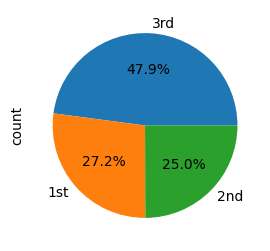

In [12]:
res = df_copy.passengerClass.value_counts()
res.plot(kind='pie', figsize=(4,3), autopct='%1.1f%%')
plt.show()

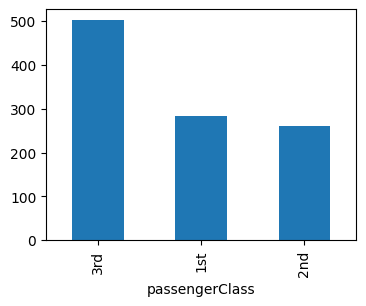

In [13]:
res = df_copy.passengerClass.value_counts()
res.plot(kind='bar', figsize=(4,3))
plt.show()

<Axes: title={'center': 'age'}, ylabel='Frequency'>

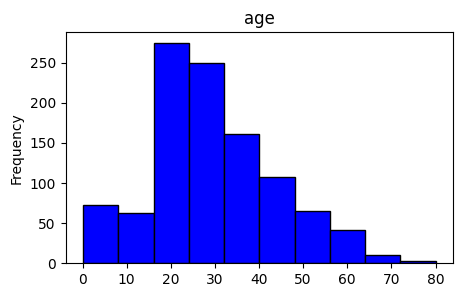

In [14]:

res = df_copy['age']
res.plot(kind='hist', title = 'age', edgecolor='black',color= 'blue', figsize =( 5,3))

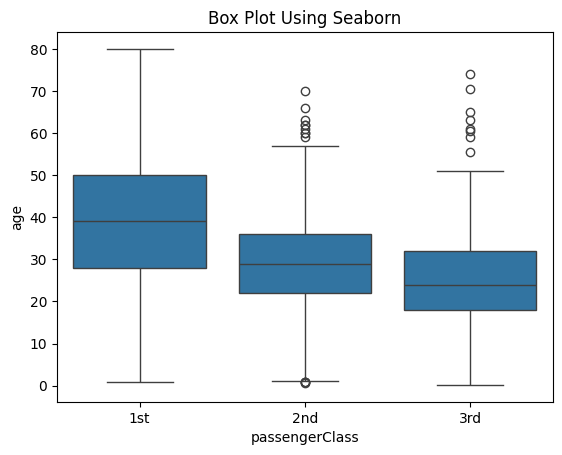

In [15]:
import seaborn as sns


sns.boxplot(data=df_copy, x="passengerClass", y="age")

# 3. Display the plot
plt.title("Box Plot Using Seaborn")
plt.show()


# 4. Data Preprocessing

In [ ]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy['passengerClass'] = le.fit_transform(df_copy['passengerClass'])
df_copy['survived'] = le.fit_transform(df_copy['survived'])
df_copy.head(14)

In [ ]:
print(df_copy.head(2))
hist_map={'female':0, 'male':1}
df_copy['sex'] = df_copy['sex'].map(hist_map)
df_copy.head(2)

In [18]:
# Returns a fresh copy of the DataFrame without 'column_to_exclude'
new_df = df_copy.drop(columns=['names'])

In [19]:

import pandas as pd

category_cols = ['sex', 'passengerClass']

df_use_dummies = pd.get_dummies(
    new_df,
    columns=category_cols,
    dtype=int
)

print("--------")
print(df_use_dummies.dtypes)

df_use_dummies.head(2)

--------
survived              int64
age                 float64
sex_0                 int64
sex_1                 int64
passengerClass_0      int64
passengerClass_1      int64
passengerClass_2      int64
dtype: object


,survived,age,sex_0,sex_1,passengerClass_0,passengerClass_1,passengerClass_2
0,1,29.0000,1,0,1,0,0
1,1,0.9167,0,1,1,0,0


In [20]:
print(new_df.columns)

cols_used = [
    'sex',
    'age',
    'passengerClass'
]

# Separate data part
data =new_df[cols_used]

# Get target
target = new_df['survived']

print(data.shape)
print(target.shape)
print(target.head(2))

data.head(3)

Index(['survived', 'sex', 'age', 'passengerClass'], dtype='object')
(1046, 3)
(1046,)
0    1
1    1
Name: survived, dtype: int64


,sex,age,passengerClass
0,0,29.0000,0
1,1,0.9167,0
2,0,2.0000,0


In [21]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) using df_use_dummies
X = df_use_dummies.drop('survived', axis=1)
y = df_use_dummies['survived']

# Split the data into training and testing sets
data_train, data_test, target_train, target_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {data_train.shape}")
print(f"Testing data shape: {data_test.shape}")


Training data shape: (732, 6)
Testing data shape: (314, 6)


# 5. Machine Learning Models

KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Try different k numbers
k_values = [3, 5, 7]

for k in k_values:
    print(f"\n--- K-Nearest Neighbors Classifier (k={k}) ---")
    knn_classifier = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn_classifier.fit(data_train, target_train)

    # Make predictions
    predicted_knn = knn_classifier.predict(data_test)

    # Evaluate the model
    report_knn = classification_report(target_test, predicted_knn)
    print("Classification Report:")
    print(report_knn)

    matrix_knn = confusion_matrix(target_test, predicted_knn)
    print('-------- Confusion Matrix')
    print(matrix_knn)


--- K-Nearest Neighbors Classifier (k=3) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       175
           1       0.75      0.63      0.68       139

    accuracy                           0.74       314
   macro avg       0.74      0.73      0.73       314
weighted avg       0.74      0.74      0.74       314

-------- Confusion Matrix
[[145  30]
 [ 51  88]]

--- K-Nearest Neighbors Classifier (k=5) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       175
           1       0.73      0.63      0.68       139

    accuracy                           0.74       314
   macro avg       0.74      0.73      0.73       314
weighted avg       0.74      0.74      0.73       314

-------- Confusion Matrix
[[143  32]
 [ 51  88]]

--- K-Nearest Neighbors Classifier (k=7) ---
Classification Report:
              precision    recall  f1-sco

DecisionTreeClassifier

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Decision Tree Classifier ---")
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_classifier.fit(data_train, target_train)

# Make predictions
predicted_dt = decision_tree_classifier.predict(data_test)

# Evaluate the model
report_dt = classification_report(target_test, predicted_dt)
print("Classification Report:")
print(report_dt)

matrix_dt = confusion_matrix(target_test, predicted_dt)
print('-------- Confusion Matrix')
print(matrix_dt)


--- Decision Tree Classifier ---
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.83      0.78       175
           1       0.74      0.60      0.67       139

    accuracy                           0.73       314
   macro avg       0.73      0.72      0.72       314
weighted avg       0.73      0.73      0.73       314

-------- Confusion Matrix
[[146  29]
 [ 55  84]]


LinearDiscriminantAnalysis

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

predictions = lda.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"LDA Model Accuracy: {accuracy:.2f}")
print(classification_report(y_test, predictions))


LDA Model Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       120
           1       0.69      0.63      0.66        90

    accuracy                           0.72       210
   macro avg       0.71      0.71      0.71       210
weighted avg       0.72      0.72      0.72       210



## Model Evaluation Results

| Classifier | TP   | FP  | TN    | FN   | Precision | Recall | F1-score | Accuracy |
|:-----------|:-----|:----|:------|:-----|:----------|:-------|:---------|:---------|
| KNN (k=3)  | 88 | 30 | 145 | 51 | .74      | .74   | 0.74     | 0.74    |
| KNN (k=5)  |88 | 32 | 143 | 51 | 0.74      | 0.74   | 0.73     | 0.74     |
| KNN (k=7)  | 82 | 30 | 145 | 57 | 0.72      | 0.72   | 0.72     | 0.72     |
| Decision Tree | 84 | 29 | 146 | 55  | 0.73      | 0.73   | 0.73     | 0.73     |
|          |          |
